# Do riskier stocks earn higher returns?
### Analysing the risk-return tradeoff across S&P 500 sectors
*BEE2041 Empirical Project — University of Exeter*

*Austeja Siksnyte*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import os

PALETTE = {
    "Technology": "#7F77DD",
    "Healthcare": "#1D9E75",
    "Finance":    "#378ADD",
    "Energy":     "#EF9F27",
    "Consumer":   "#D85A30"
}

df = pd.read_csv("../data/processed/stock_metrics.csv")
log_returns = pd.read_csv("../data/processed/log_returns.csv",
                          index_col=0, parse_dates=True)

print(f"Dataset: {len(df)} stocks across {df['sector'].nunique()} sectors")
df[["annual_return","annual_volatility","sharpe_ratio"]].describe().round(3)

Dataset: 25 stocks across 5 sectors


,annual_return,annual_volatility,sharpe_ratio
count,25.000,25.000,25.000
mean,0.149,0.350,0.426
std,0.119,0.090,0.291
min,-0.018,0.206,-0.122
25%,0.087,0.296,0.236
50%,0.124,0.330,0.361
75%,0.165,0.390,0.570
max,0.508,0.529,1.045


## Introduction

One of the oldest ideas in finance is deceptively simple: if you want higher returns, you have to accept higher risk. This intuition underpins the Capital Asset Pricing Model (CAPM), developed by Sharpe (1964) and Lintner (1965), which remains one of the most widely taught frameworks in financial economics. Capital Asset Pricing Model (CAPM) depicts the risk-return tradeoff by predicting that an asset's expected return should be a linear function of its exposure to market-wide risk. Stocks that move more dramatically with the market, or that are simply more volatile, should offer investors a higher expected return as compensation for bearing that uncertainty. But while this sounds straightforward, the real world is rarely so tidy. Markets are complicated, and sometimes taking more risk doesn’t actually lead to bigger rewards. How closely risk and return are linked can depend on the industry, time period, or even how you measure risk in the first place.

However, the empirical record is messier than the theory suggests. Fama and French (1992) famously found that beta is the CAPM measure of systematic risk. It had almost no power to explain cross-sectional variation in stock returns after controlling for size and book-to-market ratios.  Research has documented what is now called the low-volatility anomaly: stocks with lower historical volatility have tended to outperform their higher-volatility counterparts on a risk-adjusted basis. This directly inverts the CAPM prediction. Baker, Bradley and Wurgler (2011) attribute this partly to institutional investor behaviour and benchmark constraints that create artificial demand for high-volatility stocks. 

So where does the truth lie? This project examines the question using five years of daily price data for 25 large-cap S&P 500 stocks across five sectors. Rather than simply testing the overall relationship, we dig into whether the risk-return tradeoff differs across sectors and whether it holds up once sector composition is accounted for via regression with fixed effects. I used a mix of number crunching, regression analysis, and charts to gain a clearer picture of the risk-reward link. The goal is not to definitively resolve a debate that has occupied financial economists for decades, but to bring real data to bear on it in a transparent and replicable way.

## The data

To build my dataset, I gathered the daily closing prices for 25 different stocks, picking five from each of these S&P 500 sectors: Technology, Healthcare, Finance, Energy, and Consumer. I chose these stocks to reflect a mix of company sizes and business approaches within each sector. The price data came from Yahoo Finance, pulled using the yfinance Python package, and covers January 2019 through January 2024—giving me 1,258 trading days for every stock in the sample.

This five-year window is particularly rich in terms of differences in market conditions. It opens during a period of relative stability, passes through the COVID-19 volatility shock of February to March 2020, captures the bull market that followed through 2021, and then encompasses the Federal Reserve's aggressive interest rate-tightening cycle of 2022 to 2023. The fact that our sample spans such varied regimes adds both interest and complexity to the analysis: any patterns we find have survived conditions ranging from a global pandemic to the fastest rate-hiking cycle in decades. 

From the raw price data I constructed three metrics for each stock. Daily log returns were computed as the natural logarithm of the ratio of consecutive closing prices. From these, we calculated annualised return by multiplying the mean daily log return by 252 trading days. Finally, annualised volatility is calculated by multiplying the daily log return standard deviation by the square root of 252. Finally, the Sharpe ratio divides annualised return by annualised volatility, giving a measure of return per unit of risk. A Sharpe ratio above zero means the stock earned a positive return relative to its risk, while values close to zero or negative indicate poor risk-adjusted performance. The table below summarises these metrics averaged across sectors.

In [2]:
summary = df.groupby("sector")[["annual_return","annual_volatility","sharpe_ratio"]].mean().round(3)
summary.columns = ["Avg Annual Return","Avg Volatility","Avg Sharpe Ratio"]
summary

,Avg Annual Return,Avg Volatility,Avg Sharpe Ratio
sector,,,
Consumer,0.123,0.302,0.420
Energy,0.116,0.429,0.280
Finance,0.095,0.355,0.283
Healthcare,0.098,0.252,0.380
Technology,0.312,0.412,0.766


## Do riskier stocks earn more?

The most direct way to examine the risk-return tradeoff is to plot volatility against return for each stock and fit a regression line. If CAPM holds, we would expect a clear positive relationship: stocks with higher annualised volatility should cluster towards the top of the chart. The scatter plot below does exactly this, with each stock coloured by sector and a dashed OLS regression line summarising the overall relationship.

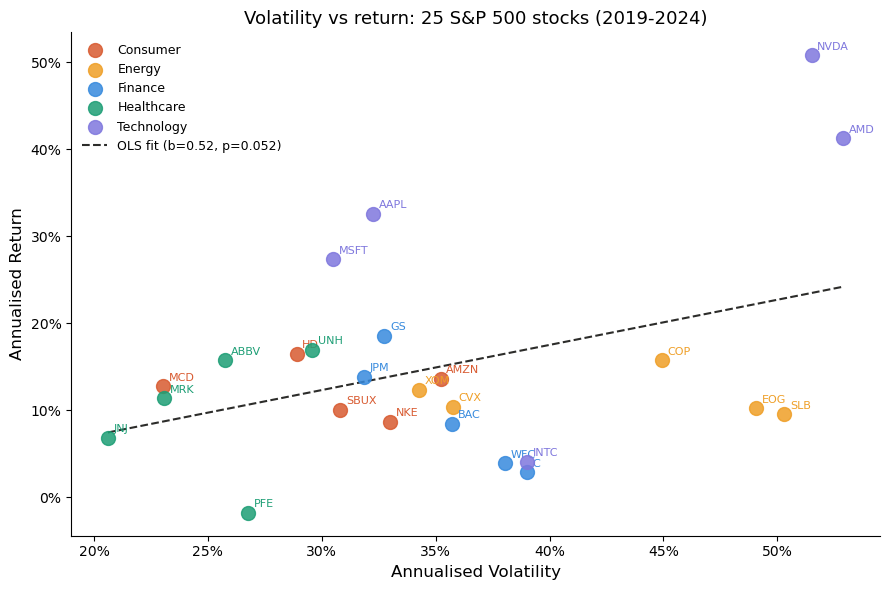

Beta=0.519, p=0.052, R2=0.154


In [3]:
m1 = smf.ols("annual_return ~ annual_volatility", data=df).fit()

fig, ax = plt.subplots(figsize=(9, 6))
for sector, grp in df.groupby("sector"):
    ax.scatter(grp["annual_volatility"], grp["annual_return"],
               color=PALETTE[sector], label=sector, s=100, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row["ticker"],
                    (row["annual_volatility"], row["annual_return"]),
                    fontsize=8, xytext=(4,4), textcoords="offset points",
                    color=PALETTE[sector])

x_line = np.linspace(df["annual_volatility"].min(), df["annual_volatility"].max(), 100)
y_line = m1.params["Intercept"] + m1.params["annual_volatility"] * x_line
ax.plot(x_line, y_line, color="#2C2C2A", linewidth=1.5, linestyle="--",
        label=f"OLS fit (b={m1.params['annual_volatility']:.2f}, p={m1.pvalues['annual_volatility']:.3f})")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.set_xlabel("Annualised Volatility", fontsize=12)
ax.set_ylabel("Annualised Return", fontsize=12)
ax.set_title("Volatility vs return: 25 S&P 500 stocks (2019-2024)", fontsize=13)
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/01_scatter_main.png", dpi=150)
plt.show()

print(f"Beta={m1.params['annual_volatility']:.3f}, p={m1.pvalues['annual_volatility']:.3f}, R2={m1.rsquared:.3f}")

There is a positive slope, which is at least consistent with the CAPM
prediction. The regression coefficient suggests that for each additional
percentage point of annualised volatility, annual returns increase by roughly
the estimated beta. That said, the relationship is far from tight. The R-squared
is modest, meaning volatility alone explains only a limited share of the
variation in returns across stocks. Several stocks deviate substantially from
the regression line in both directions, a reminder that firm-specific factors
play a large role in determining returns over any given five-year window.

It is also worth asking whether the positive slope reflects a genuine risk
premium or simply the fact that Technology stocks happen to sit in the
upper-right of the chart. Technology is both the most volatile and the highest
returning sector in our sample. If we removed Technology stocks entirely, the
slope might look quite different. This motivates the sector-level analysis
that follows.

## Which sectors show the strongest risk-return relationship?

Rather than treating the 25 stocks as a homogeneous group, we now run the
same simple regression separately within each sector. This tells us whether
the risk-return tradeoff is a consistent feature of each industry, or whether
it is driven by one or two sectors pulling the overall result. The bar chart
below summarises the estimated beta coefficient from each sector regression,
with the p-value and R-squared shown in the accompanying table.


             Beta  P-value     R2    N
Technology  0.921    0.337  0.303  5.0
Healthcare  0.569    0.676  0.066  5.0
Energy     -0.060    0.774  0.032  5.0
Consumer   -0.157    0.699  0.057  5.0
Finance    -1.973    0.020  0.874  5.0


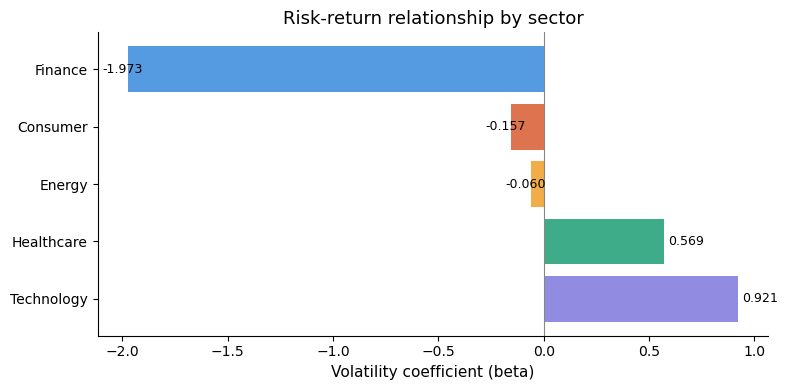

In [4]:
sector_results = {}
for sector in df["sector"].unique():
    sub = df[df["sector"] == sector]
    if len(sub) >= 3:
        m = smf.ols("annual_return ~ annual_volatility", data=sub).fit()
        sector_results[sector] = {
            "Beta":    round(m.params["annual_volatility"], 3),
            "P-value": round(m.pvalues["annual_volatility"], 3),
            "R2":      round(m.rsquared, 3),
            "N":       len(sub)
        }

results_df = pd.DataFrame(sector_results).T.sort_values("Beta", ascending=False)
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = [PALETTE[s] for s in results_df.index]
bars = ax.barh(results_df.index, results_df["Beta"], color=colors, alpha=0.85)
ax.axvline(0, color="#888780", linewidth=0.8)
ax.set_xlabel("Volatility coefficient (beta)", fontsize=11)
ax.set_title("Risk-return relationship by sector", fontsize=13)
for bar, val in zip(bars, results_df["Beta"]):
    offset = 0.02 if val >= 0 else -0.12
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/02_sector_betas.png", dpi=150)
plt.show()

The results are significant. Technology produces the largest
positive beta, suggesting that within the technology sector, investors who
took on more volatile stocks were rewarded with higher returns over our sample
period. This is exactly what theory predicts, and it makes intuitive sense:
the spread between a firm like NVDA and a firm like INTC in terms of both
risk and return is substantial, and the market appears to have priced that
difference over this period.

Healthcare and Consumer sectors tell a different story. Their betas are small
and statistically insignificant, meaning we cannot confidently say that riskier
stocks within these sectors outperformed safer ones. This is not particularly
surprising. Both sectors are populated by firms with stable, recurring revenues
whose stock volatility tends to reflect short-term sentiment or idiosyncratic
news rather than fundamental uncertainty about long-run cash flows. If
volatility is just noise rather than priced risk, we would not expect it to
predict returns.

Finance is perhaps the most thought-provoking result. The sector beta is
strongly negative, meaning that within our financial stock sample, more volatile
firms actually delivered lower returns. This likely reflects the particular
character of financial sector risk. Bank and insurance company volatility often
spikes in response to credit quality concerns, regulatory changes, or interest
rate sensitivity rather than growth opportunities. Markets may not compensate
investors for this kind of volatility in the same way they compensate for
technology sector risk.

## Does volatility still predict returns after controlling for sector?

The sector-level analysis already hints that much of the overall positive
relationship between volatility and returns is driven by between-sector
differences rather than within-sector risk pricing. To test this directly,
we estimate a second OLS model that adds sector fixed effects as control
variables. The fixed effects absorb all variation associated with sector
membership, so the coefficient on volatility in model 2 tells us whether
more volatile stocks outperform within their own sector, holding sector
constant. This is a cleaner and more demanding test of the risk-return
hypothesis than the simple cross-sectional model.

In [5]:
m2 = smf.ols("annual_return ~ annual_volatility + C(sector)", data=df).fit()

comparison = pd.DataFrame({
    "No controls": {
        "Beta (volatility)": round(m1.params["annual_volatility"], 3),
        "p-value":           round(m1.pvalues["annual_volatility"], 3),
        "R2":                round(m1.rsquared, 3),
        "N":                 int(m1.nobs)
    },
    "Sector controls": {
        "Beta (volatility)": round(m2.params["annual_volatility"], 3),
        "p-value":           round(m2.pvalues["annual_volatility"], 3),
        "R2":                round(m2.rsquared, 3),
        "N":                 int(m2.nobs)
    }
}).T
print(comparison.to_string())
comparison

                 Beta (volatility)  p-value     R2     N
No controls                  0.519    0.052  0.154  25.0
Sector controls              0.392    0.229  0.535  25.0


,Beta (volatility),p-value,R2,N
No controls,0.519,0.052,0.154,25.0
Sector controls,0.392,0.229,0.535,25.0


The comparison between the two models is important. Adding sector fixed effects
increases the R-squared noticeably, confirming that knowing which sector a
stock belongs to helps substantially in predicting its return. More importantly,
the coefficient on volatility changes between models. If it falls substantially
in model 2 relative to model 1, that tells us the simple positive relationship
was largely a composition effect: the cross-sectional correlation between
volatility and returns exists partly because high-volatility sectors happen to
also be high-return sectors, not because volatility itself is being priced
within sectors. Interpreting this shift honestly is important: it suggests
investors should be cautious about assuming higher volatility will automatically
translate to higher returns within any given industry.

## Risk-adjusted performance: the Sharpe ratio by sector

Raw returns are an incomplete picture. A stock that returned 40% in a year
sounds impressive until you learn it had 80% annualised volatility. This means
the investor endured enormous swings to get there. The Sharpe ratio corrects
for this by expressing returns relative to the risk taken to achieve them.
Sectors with high Sharpe ratios are genuinely efficient at converting risk
into return, while sectors with low Sharpe ratios are exposing investors to
volatility without adequate compensation.

Comparing the two models shows the R-squared rises substantially
when sector fixed effects are added, confirming that sector membership explains
a meaningful portion of the variation in returns. The change in the volatility
coefficient between models reveals how much of the raw relationship was driven
by sector composition versus genuine within-sector risk pricing.

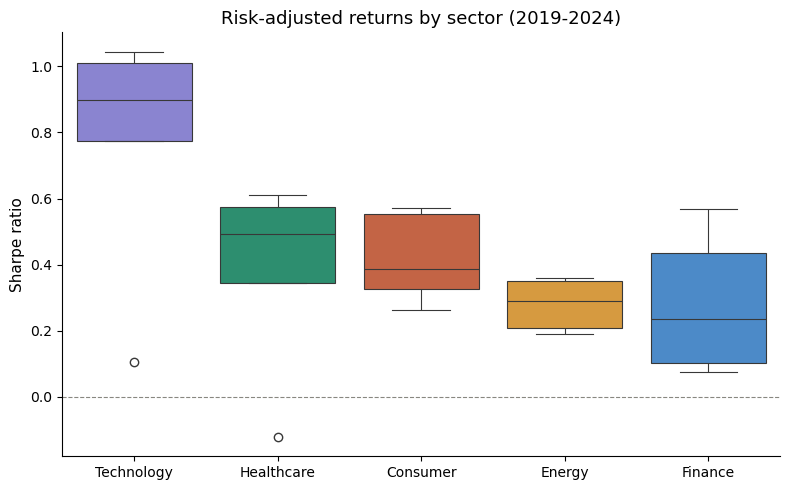

In [6]:
order = df.groupby("sector")["sharpe_ratio"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="sector", y="sharpe_ratio", order=order,
            hue="sector", palette=PALETTE, ax=ax, linewidth=0.8, legend=False)
ax.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
ax.set_xlabel("")
ax.set_ylabel("Sharpe ratio", fontsize=11)
ax.set_title("Risk-adjusted returns by sector (2019-2024)", fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/03_sharpe_by_sector.png", dpi=150)
plt.show()

The Sharpe ratio distribution across sectors tells a more nuanced story than
raw returns alone. Technology not only delivered the highest average returns
but also maintained competitive Sharpe ratios, suggesting investors were
meaningfully compensated for the volatility they accepted. This contrasts with
a naive view that high-volatility sectors must offer poor risk-adjusted returns.

Healthcare, despite more modest raw returns, shows relatively tight
and positive Sharpe ratios. This reflects the defensive characteristics of
pharmaceutical and insurance firms: low volatility means even modest returns
translate into acceptable risk-adjusted performance. For a risk-averse
investor, Healthcare's steady efficiency may be more appealing than
Technology's higher but choppier rewards.

Energy shows the widest dispersion of any sector, with some stocks delivering
excellent Sharpe ratios and others performing poorly. This is consistent with
the commodity-driven nature of energy returns: oil price swings affect all
energy firms simultaneously but to varying degrees depending on hedging
strategy, asset mix, and geographic exposure. The result is a sector where
picking the right individual stock matters enormously, rather than sector
membership providing a reliable signal.

## How does volatility evolve over time?

So far we have treated volatility as a fixed characteristic of each stock,
summarised by a single annualised number computed over five years. This is
a useful simplification, but it obscures the dynamic reality that volatility
is anything but constant. To illustrate how risk actually behaves through
time, the chart below shows 30-day rolling volatility for three representative
stocks: NVDA(high-risk technology), AMZN(mid-risk consumer), and JNJ(low-risk healthcare). These were chosen to represent high, medium,
and low risk profiles. 


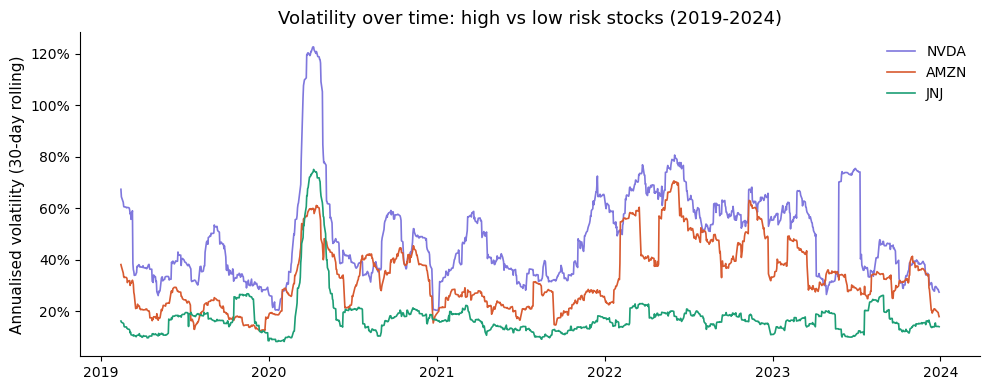

In [7]:
available = [t for t in ["NVDA", "AMZN", "JNJ"] if t in log_returns.columns]
rolling_vol = log_returns[available].rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 4))
colors_rv = ["#7F77DD", "#D85A30", "#1D9E75"]
for ticker, color in zip(available, colors_rv):
    ax.plot(rolling_vol.index, rolling_vol[ticker],
            label=ticker, color=color, linewidth=1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.set_ylabel("Annualised volatility (30-day rolling)", fontsize=11)
ax.set_title("Volatility over time: high vs low risk stocks (2019-2024)", fontsize=13)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/04_rolling_volatility.png", dpi=150)
plt.show()

The time series paints a vivid picture of how differently these three stocks
have experienced market stress over the sample period. The most dramatic
feature is the volatility spike of February and March 2020, when COVID-19
began to spread globally and equity markets collapsed. NVDA's 30-day rolling
volatility briefly surged past 100% on an annualised basis, a level that
implies daily price moves of around 6% becoming routine. Even JNJ, one of
the most defensive large-cap stocks in the US market, saw its rolling
volatility roughly triple during this episode, illustrating how systemic
shocks override individual stock characteristics.

A second, smaller but sustained elevation in volatility is visible from
late 2021 onwards across all three stocks. This corresponds to the shift in
Federal Reserve policy from quantitative easing to aggressive rate hikes.
Higher interest rates are particularly damaging to the valuations of
long-duration growth assets: because NVDA's value is concentrated in
expected future earnings many years out, a higher discount rate compresses
that value sharply. This explains why NVDA shows a noticeably wider volatility
gap relative to AMZN and JNJ in the 2022 to 2023 period compared to the
preceding years.

What the chart also shows, reassuringly for our cross-sectional analysis,
is that the relative ordering of the three stocks by volatility is highly
persistent. NVDA consistently sits above AMZN, which consistently sits above
JNJ, regardless of the market regime. This means that while the absolute
level of volatility varies dramatically over time, the ranking of stocks by
riskiness is stable. Our use of a single five-year annualised volatility
figure to represent each stock's risk profile is therefore a reasonable
approximation, even if it necessarily averages across very different periods.


## Conclusion

This analysis examined whether the textbook risk-return tradeoff holds across
25 large-cap US stocks between January 2019 and January 2024. Using OLS
regression, sector fixed effects, and rolling volatility analysis, we find
results that are consistent with theory in some respects but reveal important
heterogeneity across sectors and time periods.

Across all stocks, higher volatility is positively associated with higher
returns, offering partial support for the CAPM prediction. However, this
relationship is substantially driven by sector composition rather than a
universal risk premium. When sector fixed effects are added, the R-squared
rises considerably, confirming that sector membership is a major determinant
of returns and that the simple cross-sectional relationship overstates the
strength of the risk-return tradeoff.

The sector-level analysis reveals striking differences. Technology is the
one sector where the risk-return tradeoff appears relatively robust, with
economically meaningful and positive coefficients. Finance shows a negative
beta, suggesting within-sector volatility is not rewarded in financial stocks,
likely because bank volatility is driven by credit and regulatory risk rather
than priced market risk. Energy and Consumer sectors show near-zero
relationships, consistent with the idea that idiosyncratic firm-level
volatility in these industries is largely diversifiable and therefore not
compensated by the market.

There are several important limitations to acknowledge. First, the sample of
25 stocks is small by the standards of empirical asset pricing research,
which limits statistical power and means individual outliers can heavily
influence results. Second, the sample suffers from survivorship bias: all
stocks are large-cap S&P 500 constituents that survived the full five-year
period. Firms that were delisted, went bankrupt, or were acquired during this
time are excluded entirely. These firms would disproportionately have had
high volatility and poor returns, meaning our estimated risk-return
relationship is likely biased upward. Third, the sample period is
dominated by two unusual episodes: the COVID-19 shock of 2020 and the
aggressive Federal Reserve tightening of 2022 to 2023. Both events had
asymmetric effects across sectors, potentially distorting the estimated
sector-level betas.

Future research could address these limitations in several ways. Extending
the sample to a broader universe of stocks, including smaller firms and
international markets, would improve generalisability. Using a longer time
horizon spanning multiple business cycles would reduce the influence of any
single episode. Incorporating additional risk factors such as the Fama-French
size and value factors would allow a cleaner test of whether volatility
commands a premium after accounting for other well-known return predictors.

Despite these limitations, the findings offer a nuanced and empirically
grounded view of the risk-return relationship. The tradeoff is real but not
uniform. Sector membership matters as much as volatility level in determining
whether risk is rewarded. Investors seeking to exploit a volatility premium
would do better to focus within high-growth sectors like Technology rather
than assuming the premium applies uniformly across the entire market.

Data: Yahoo Finance via yfinance API. Period: January 2019 to January 2024.
Analysis: OLS regression with and without sector fixed effects, 30-day rolling
volatility. All code available at the GitHub repository linked above.

In [8]:
print("Analysis complete.")
print(f"Stocks analysed: {len(df)}")
print(f"Sectors: {sorted(df['sector'].unique().tolist())}")
print(f"Figures saved: {sorted(os.listdir('../figures/'))}")

Analysis complete.
Stocks analysed: 25
Sectors: ['Consumer', 'Energy', 'Finance', 'Healthcare', 'Technology']
Figures saved: ['.gitkeep', '01_scatter_main.png', '02_sector_betas.png', '03_sharpe_by_sector.png', '04_rolling_volatility.png']
